In [1]:
import numpy as np
import seaborn as sns
import random
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# metod generise rcbd tabelu tako sto je popuni sa nasumicnim brojevima iz [lower, upper] --> ovo je okej jer mi radimo sa vestackim podacima
# generalno gledano to nisu nasumicne vrednosti vec izmerene vrednosti u eksperimentu
def generate_rcbd_table(n_rows = 2, n_cols = 2, lower_bound = 1, upper_bound = 30, seed=None):
    if seed is not None:
        np.random.seed(seed)

    data = np.random.randint(lower_bound, upper_bound + 1, size=(n_rows, n_cols))
    df = pd.DataFrame(data, 
                      index=[f"T{i+1}" for i in range(n_rows)],
                      columns=[f"B{j+1}" for j in range(n_cols)])
    return df

In [3]:
def calculate_sse(predicted, true, mask):
    predicted = predicted.astype(float)
    true = true.astype(float)
    error = (predicted - true) ** 2
    #print("Error matrix:\n", error)
    masked_error = error * mask
    #print("Masked error matrix:\n", masked_error)
    sse = np.sum(masked_error)
    return sse

<h4>Test primeri i vizualizacija razlike<h4>

In [4]:
# originalna RCBD tabela (npr. 3 tretmana x 3 bloka)
true_table = generate_rcbd_table(3, 3, 1, 20, 42)
display(true_table)
# maska:
mask = pd.DataFrame(0, index=true_table.index, columns=true_table.columns)
# izaberemo proizvoljna polja za promenu
mask.iloc[0, 1] = 1
mask.iloc[2, 2] = 1

# predlozene vrednosti koje bi GA dao kao rešenja
predicted_table = true_table.copy().astype(float)
predicted_table.iloc[0, 1] = 19.5
predicted_table.iloc[2, 2] = 12.5 
sse = calculate_sse(predicted_table.values, true_table.values, mask.values)
print(f"SSE: {sse:.4f}")

,B1,B2,B3
T1,7,20,15
T2,11,8,7
T3,19,11,11


SSE: 2.5000


In [5]:
error_table = (predicted_table - true_table)
masked_error_table = error_table * mask

print("Razlika (samo na pozicijama sa greškom):")
display(masked_error_table)

Razlika (samo na pozicijama sa greškom):


,B1,B2,B3
T1,0.0,-0.5,0.0
T2,0.0,0.0,0.0
T3,0.0,0.0,1.5


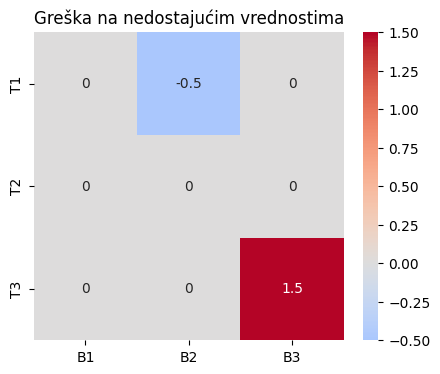

In [6]:
plt.figure(figsize=(5,4))
sns.heatmap(masked_error_table, annot=True, cmap="coolwarm", center=0)
plt.title("Greška na nedostajućim vrednostima")
plt.show()

In [7]:
#nasumicno uklanjanje jedne vrednosti iz rcbd tabele
def hide_random_value(table: pd.DataFrame):
    
    table_hidden = table.copy() #kopija tabele sa jednom vrednošću zamenjenom sa np.nan

    rows, cols = table.shape
    i = random.randint(0, rows - 1)
    j = random.randint(0, cols - 1)
    #(i,j) je pozicija gde je vrednost uklonjena

    true_value = table_hidden.iat[i, j] #originalna vrednost na (i,j) poziciji
    table_hidden.iat[i, j] = np.nan 

    return table_hidden, (i, j), true_value

In [8]:
#proba funkcije za uklanjanje jedne vrednosti
df = generate_rcbd_table(5, 5, 10, 30, 42)
print("Originalna tabela:")
display(df)

df_hidden, pos, original_val = hide_random_value(df)

print("\nTabela sa skrivenom vrednošću:")
display(df_hidden)

print(f"\nUklonjena vrednost: {original_val} na poziciji {pos}")

Originalna tabela:


,B1,B2,B3,B4,B5
T1,16,29,24,20,17
T2,30,16,28,20,20
T3,30,13,17,12,30
T4,11,21,15,11,30
T5,10,21,21,26,19



Tabela sa skrivenom vrednošću:


,B1,B2,B3,B4,B5
T1,16,29,24,20.0,17
T2,30,16,28,NaN,20
T3,30,13,17,12.0,30
T4,11,21,15,11.0,30
T5,10,21,21,26.0,19



Uklonjena vrednost: 20 na poziciji (1, 3)
